In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 10})
import ants


In [2]:
import sys
sys.path.append('../src/')

%load_ext autoreload
%autoreload 2
# Importing our custom module(s)
import utils


In [3]:
csv_filename = 'ADNI1_Complete_1Yr_1.5T.csv'
nifti_dir = '/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T'
labels_df = pd.read_csv(f'{nifti_dir}/{csv_filename}')
print(labels_df.shape)
print(len(labels_df[["Subject"]].value_counts()))
labels_df.head()


(2294, 12)
639


,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I97327,941_S_1311,MCI,M,69,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Pre-processed,3/02/2007,NiFTI,Yes
1,I97341,941_S_1311,MCI,M,70,m06,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Pre-processed,9/27/2007,NiFTI,Yes
2,I112538,941_S_1311,MCI,M,70,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Pre-processed,6/01/2008,NiFTI,Yes
3,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Pre-processed,1/30/2007,NiFTI,Yes
4,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Pre-processed,8/24/2007,NiFTI,Yes


In [4]:
print(labels_df['Group'].value_counts())
labels_df['Alzheimer\'s'] = (labels_df['Group'] == 'AD').astype(int)


MCI    1113
CN      705
AD      476
Name: Group, dtype: int64


In [5]:
def get_adni1_nifti_paths(row, root):
    subject_id, image_id = row['Subject'], row['Image Data ID']
    paths = [
        f'{root}/{filename}'
        for root, _, files in os.walk(f'{nifti_dir}/{subject_id}')
        for filename in files
        if filename.endswith(f'{image_id}.nii')
    ]
    assert len(paths) == 1
    return paths

labels_df['paths'] = labels_df.apply(get_adni1_nifti_paths, root=nifti_dir, axis=1)
labels_df.head()


,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded,Alzheimer's,paths
0,I97327,941_S_1311,MCI,M,69,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Pre-processed,3/02/2007,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...
1,I97341,941_S_1311,MCI,M,70,m06,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Pre-processed,9/27/2007,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...
2,I112538,941_S_1311,MCI,M,70,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Pre-processed,6/01/2008,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...
3,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Pre-processed,1/30/2007,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...
4,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Pre-processed,8/24/2007,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...


(192, 192, 160)


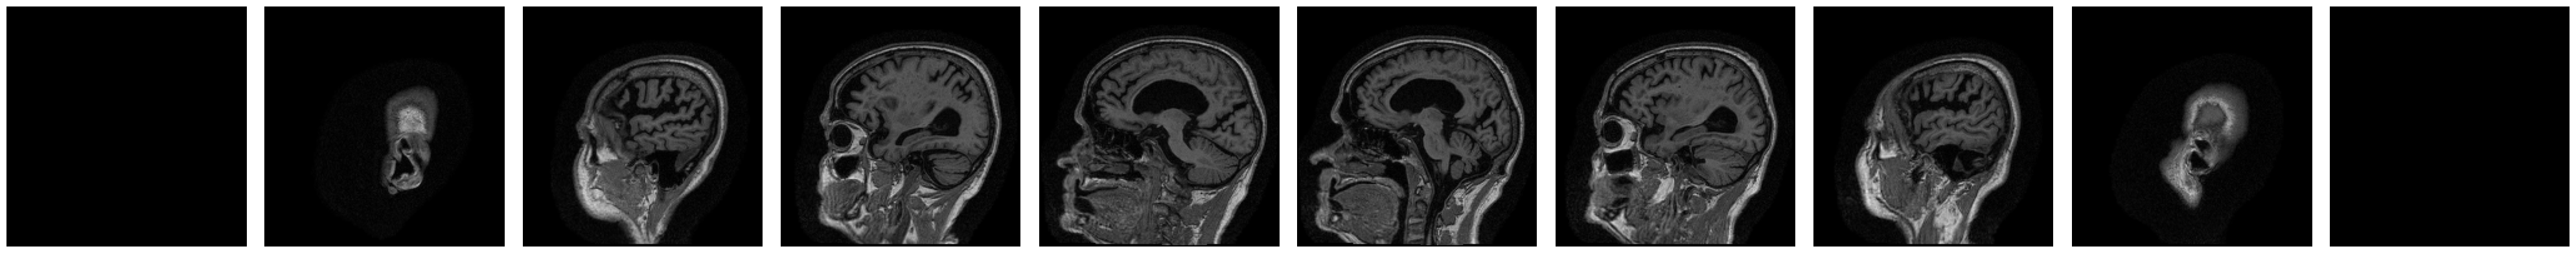

In [6]:
image = ants.image_read(labels_df.iloc[0].paths[0]).numpy()
print(image.shape)
linspace = np.linspace(0, image.shape[-1] - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(image[:,:,j], cmap='gray', vmin=np.min(image), vmax=np.max(image))
    axs[i].set_axis_off()
    
fig.tight_layout()
plt.show()


In [7]:
numpy_dir = '/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy'
starts = np.linspace(0, 2294, num=11).astype(int)[:-1]
stops = np.linspace(0, 2294, num=11).astype(int)[1:]
for start, stop in zip(starts, stops):
    print(f'    \"python ../src/preprocess_adni1_mri.py --csv_filename=\'{csv_filename}\' --nifti_dir=\'{nifti_dir}\' --numpy_dir=\'{numpy_dir}\' --start={start} --stop={stop}\"')
    

    "python ../src/preprocess_adni1_mri.py --csv_filename='ADNI1_Complete_1Yr_1.5T.csv' --nifti_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T' --numpy_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy' --start=0 --stop=229"
    "python ../src/preprocess_adni1_mri.py --csv_filename='ADNI1_Complete_1Yr_1.5T.csv' --nifti_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T' --numpy_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy' --start=229 --stop=458"
    "python ../src/preprocess_adni1_mri.py --csv_filename='ADNI1_Complete_1Yr_1.5T.csv' --nifti_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T' --numpy_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T_numpy' --start=458 --stop=688"
    "python ../src/preprocess_adni1_mri.py --csv_filename='ADNI1_Complete_1Yr_1.5T.csv' --nifti_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Complete_1Yr_1.5T' --numpy_dir='/cluster/tufts/hugheslab/datasets/ADNI1_Com

In [8]:
def get_adni1_numpy_path(row, root):
    subject_id, image_id = row['Subject'], row['Image Data ID']
    return f'{root}/{subject_id}__{image_id}.npz'

labels_df['path'] = labels_df.apply(get_adni1_numpy_path, root=numpy_dir, axis=1)
labels_df.to_csv(f'{numpy_dir}/labels.csv', index=False)
labels_df.head()


,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded,Alzheimer's,paths,path
0,I97327,941_S_1311,MCI,M,69,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Pre-processed,3/02/2007,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...,/cluster/tufts/hugheslab/datasets/ADNI1_Comple...
1,I97341,941_S_1311,MCI,M,70,m06,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Pre-processed,9/27/2007,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...,/cluster/tufts/hugheslab/datasets/ADNI1_Comple...
2,I112538,941_S_1311,MCI,M,70,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Pre-processed,6/01/2008,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...,/cluster/tufts/hugheslab/datasets/ADNI1_Comple...
3,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Pre-processed,1/30/2007,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...,/cluster/tufts/hugheslab/datasets/ADNI1_Comple...
4,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Pre-processed,8/24/2007,NiFTI,Yes,0,[/cluster/tufts/hugheslab/datasets/ADNI1_Compl...,/cluster/tufts/hugheslab/datasets/ADNI1_Comple...


(169, 208, 179)


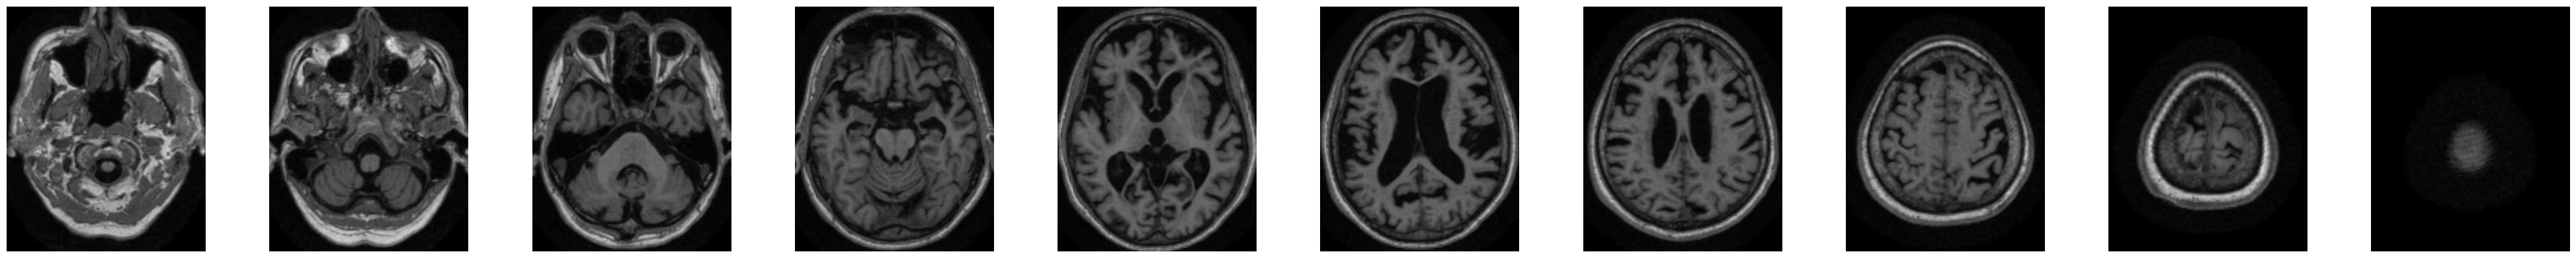

In [9]:
image = np.load(labels_df.iloc[0].path)['arr_0'][0]
print(image.shape)
linspace = np.linspace(0, image.shape[-1] - 1, 10).astype(int)

ncols, nrows = 10, 1
fig, axs = plt.subplots(ncols=ncols, nrows=nrows, figsize=(4*ncols,4*nrows))

for i, j in enumerate(linspace):
    axs[i].imshow(np.rot90(image[:,:,j], k=1, axes=(-2, -1)), cmap='gray', vmin=np.min(image), vmax=np.max(image))
    axs[i].set_axis_off()
    
fig.tight_layout()
plt.show()


In [7]:
################################################################################
def print_job(
    alpha, batch_size, criterion, dataset_dir, epochs, embedding_level, 
    experiments_dir, lr, pooling, save, seed, weight_decay
):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if temp_df.shape[0] == epochs:
            return
        
    embedding_level = '--embedding_level ' if embedding_level else ''
    save = '--save ' if save else ''
    
    command = (
        f'python ../src/adni1.py '
        f'--alpha={alpha} '
        f'--batch_size={batch_size} '
        f'--criterion=\'{criterion}\' '
        f'--dataset_dir=\'{dataset_dir}\' '
        f'--epochs={epochs} '
        f'{embedding_level}'
        f'--experiments_dir=\'{experiments_dir}\' '
        f'--lr={lr} '
        f'--model_name=\'{model_name}\' '
        f'--pooling=\'{pooling}\' '
        f'{save}'
        f'--seed={seed} '
        f'--weight_decay={weight_decay}'
    )
    
    print(f'    \"{command}\"')
    

In [8]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_ADNI1_Complete_1Yr_1.5T/ViT_B_16'
epochs = 1000
embedding_level = False
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_Complete_1Yr_1.5T_embedding_level=False' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Max', 'Mean', 'ABMIL']
poolings = ['SmAP']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/seed={seed}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              experiments_dir, lr, pooling, save, seed, weight_decay)
    

In [9]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_ADNI1_Complete_1Yr_1.5T/ViT_B_16'
epochs = 1000
embedding_level = False
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_Complete_1Yr_1.5T_embedding_level=False' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['SmAP']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ['model_name', 'seed', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['seed'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.001_criterion=L1_lr=0.1_pooling=SmAP_s...,1001,0.733775,0.391159,0.632769,0.866174,0.781437,0.739726,0.430957,0.597122,0.534577,0.451814,0.734818,0.388677,0.634603,0.926666,0.841928
1,alpha=0.01_criterion=L1_lr=0.01_pooling=SmAP_s...,2001,0.731511,0.358868,0.493569,0.582220,0.474980,0.860352,0.653059,0.624814,0.478344,0.369611,0.796162,0.607664,0.545455,0.550071,0.442832
2,alpha=0.01_criterion=L1_lr=0.1_pooling=SmAP_se...,3001,0.625000,0.347033,0.500000,0.661332,0.557076,0.723301,0.445383,0.596299,0.572980,0.460801,0.720439,0.352873,0.494932,0.643243,0.538986


In [10]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")
print(f"{df.test_auprc.mean():.3f} +/- {df.test_auprc.std():.3f}")

0.697 +/- 0.062
0.366 +/- 0.023


In [ ]:
# AUROC

# Alzheimers's
# Max: 0.632 +/- 0.048
# Mean: 0.693 +/- 0.017
# ABMIL: 0.640 +/- 0.085
# SmAP: 0.715 +/- 0.047


In [ ]:
# AUPRC

# Alzheimers's
# Max: 0.290 +/- 0.039
# Mean: 0.334 +/- 0.043
# ABMIL: 0.322 +/- 0.079
# SmAP: 0.377 +/- 0.032


In [11]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_ADNI1_Complete_1Yr_1.5T/ViT_B_16'
epochs = 1000
embedding_level = True
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_Complete_1Yr_1.5T_embedding_level=True' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['Max', 'Mean', 'ABMIL', 'TransMIL']
poolings = ['SmAP']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    temp_dataset_dir = f"{dataset_dir}/seed={seed}"

    print_job(alpha, batch_size, criterion, temp_dataset_dir, epochs, embedding_level, 
              experiments_dir, lr, pooling, save, seed, weight_decay)
    

In [12]:
alphas = [1.0, 0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06, 0.0]
beta = 0.0
batch_size = 64
criterions = ['L1']
dataset_dir = '/cluster/tufts/hugheslab/eharve06/encoded_ADNI1_Complete_1Yr_1.5T/ViT_B_16'
epochs = 1000
embedding_level = True
experiments_dir = '/cluster/tufts/hugheslab/eharve06/pooling/experiments/ADNI1_Complete_1Yr_1.5T_embedding_level=True' 
lrs = [0.1, 0.01, 0.001, 0.0001]
poolings = ['SmAP']
save = True
seeds = [1001, 2001, 3001]
weight_decay = 0.0

columns = ['model_name', 'seed', 'test_auroc', 'test_auprc', 'test_bal_acc', 'test_loss', 'test_nll', 'train_auroc', 'train_auprc', 'train_bal_acc', 'train_loss', 'train_nll', 'val_auroc', 'val_auprc', 'val_bal_acc', 'val_loss', 'val_nll']
df = pd.DataFrame(columns=columns)

for alpha, criterion, lr, pooling, seed in itertools.product(alphas, criterions, lrs, poolings, seeds):
    
    model_name = f'alpha={alpha}_criterion={criterion}_lr={lr}_pooling={pooling}_seed={seed}'
    
    if os.path.exists(f'{experiments_dir}/{model_name}.csv'):
        temp_df = pd.read_csv(f'{experiments_dir}/{model_name}.csv')
        if len(temp_df[temp_df.train_auroc > temp_df.val_auroc]):
            index = temp_df[temp_df.train_auroc > temp_df.val_auroc].val_auroc.idxmax()
            row = [model_name, seed, temp_df.test_auroc.values[index], temp_df.test_auprc.values[index], temp_df.test_bal_acc.values[index], temp_df.test_loss.values[index], temp_df.test_nll.values[index], temp_df.train_auroc.values[index], temp_df.train_auprc.values[index], temp_df.train_bal_acc.values[index], temp_df.train_loss.values[index], temp_df.train_nll.values[index], temp_df.val_auroc.values[index], temp_df.val_auprc.values[index], temp_df.val_bal_acc.values[index], temp_df.val_loss.values[index], temp_df.val_nll.values[index]]
            df.loc[len(df)] = row
        
indices = df.groupby(['seed'])['val_auroc'].idxmax()
df = df.loc[indices].reset_index(drop=True)

df.head()

,model_name,seed,test_auroc,test_auprc,test_bal_acc,test_loss,test_nll,train_auroc,train_auprc,train_bal_acc,train_loss,train_nll,val_auroc,val_auprc,val_bal_acc,val_loss,val_nll
0,alpha=0.001_criterion=L1_lr=0.01_pooling=SmAP_...,1001,0.699215,0.394656,0.673392,0.855388,0.623244,0.885063,0.702406,0.722556,0.561756,0.325237,0.693878,0.369262,0.657790,0.894334,0.662190
1,alpha=0.0001_criterion=L1_lr=0.01_pooling=SmAP...,2001,0.627628,0.282564,0.559053,1.259219,1.243753,0.999748,0.999045,0.990132,0.036756,0.021335,0.774817,0.487270,0.641621,1.001555,0.986089
2,alpha=0.001_criterion=L1_lr=0.001_pooling=SmAP...,3001,0.666034,0.292468,0.534666,0.939543,0.553167,0.917601,0.766188,0.740620,0.677865,0.291189,0.677956,0.327601,0.504223,0.951668,0.565292


In [21]:
print(f"{df.test_auroc.mean():.3f} +/- {df.test_auroc.std():.3f}")
print(f"{df.test_auprc.mean():.3f} +/- {df.test_auprc.std():.3f}")

0.316 +/- 0.059


In [5]:
# AUROC

# Alzheimers's
# Max: 0.614 +/- 0.054
# Mean: 0.689 +/- 0.030
# ABMIL: 0.673 +/- 0.050
# TransMIL: 0.593 +/- 0.067
# SmAP: 0.655 +/- 0.019


In [11]:
# AUPRC

# Alzheimers's
# Max: 0.315 +/- 0.066
# Mean: 0.326 +/- 0.038
# ABMIL: 0.325 +/- 0.030
# TransMIL: 0.260 +/- 0.025
# SmAP: 0.316 +/- 0.059
